# THỰC HÀNH 3: PHÂN CỤM KHÁCH HÀNG (CUSTOMER SEGMENTATION)

**Mục tiêu:** Ứng dụng Học không giám sát (K-Means) kết hợp với các kỹ thuật EDA chuyên sâu, làm sạch dữ liệu dựa trên bằng chứng, và hệ thống đánh giá đa chiều (Multi-metrics Evaluation) chuẩn mực Machine Learning.

In [44]:
# Cài đặt thư viện missingno nếu chưa có: !pip install missingno
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score, silhouette_samples, silhouette_score
import plotly.express as px
import plotly.graph_objects as go
import missingno as msno
import matplotlib.cm as cm
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")

# Đọc dữ liệu
df = pd.read_csv('customers.csv')

## Bước 1: Khám phá ban đầu và Làm sạch dữ liệu (Initial Inspection & Cleaning)

Trước khi tiến hành phân tích hình học và tương quan đa biến, chúng ta cần quét qua tập dữ liệu thô để định vị các giá trị rỗng (Missing values) và loại bỏ ngay các nhiễu logic hệ thống. Việc này đảm bảo các biểu đồ phân tích phía sau phản ánh đúng bản chất của tập khách hàng hợp lệ.

Số lượng dữ liệu khuyết thiếu từng cột:
CustomerID                 0
Gender                     0
Age                        0
Annual Income ($)          0
Spending Score (1-100)     0
Profession                35
Work Experience            0
Family Size                0
dtype: int64


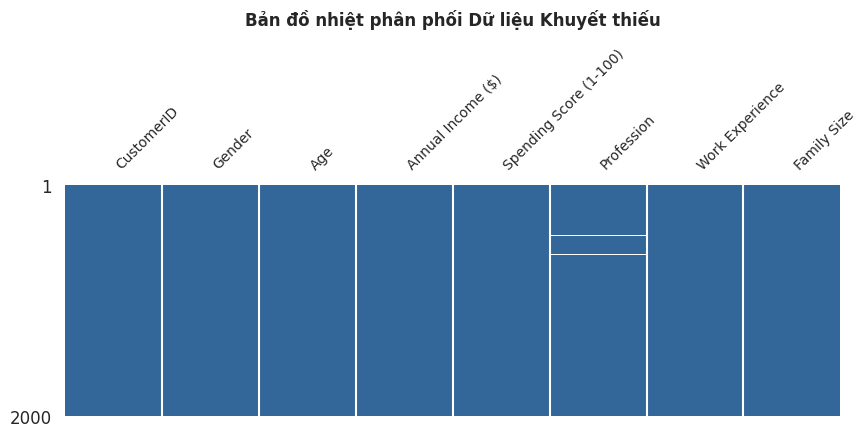


BÁO CÁO LỌC VÀ LÀM SẠCH DỮ LIỆU:
--------------------------------------------------
 - Bỏ qua 327 bản ghi vi phạm (Tuổi < 18 hoặc = 0).
 - Bỏ qua 401 bản ghi phi logic (Kinh nghiệm > Tuổi thật).
 - Bỏ qua 4 bản ghi lỗi (Thu nhập hoặc Chi tiêu bằng 0).
--------------------------------------------------
=> Tổng số bản ghi sạch giữ lại để phân tích: 1561 / 2000


In [45]:
# 1.1 Khám phá dữ liệu rỗng bằng Missingno
print("Số lượng dữ liệu khuyết thiếu từng cột:")
print(df.isnull().sum())

msno.matrix(df, figsize=(10, 3), sparkline=False, fontsize=10, color=(0.2, 0.4, 0.6))
plt.title('Bản đồ nhiệt phân phối Dữ liệu Khuyết thiếu', fontsize=12, fontweight='bold', pad=15)
plt.show()

# 1.2 Làm sạch dữ liệu triệt để (Tạo df_clean)
initial_rows = df.shape[0]
df_clean = df.copy()

print("\nBÁO CÁO LỌC VÀ LÀM SẠCH DỮ LIỆU:")
print("-" * 50)

df_clean.dropna(inplace=True)
invalid_age = df_clean[df_clean['Age'] < 18].shape[0]
invalid_exp = df_clean[df_clean['Work Experience'] > (df_clean['Age'] - 18)].shape[0]
invalid_zero = df_clean[(df_clean['Annual Income ($)'] <= 0) | (df_clean['Spending Score (1-100)'] <= 0)].shape[0]

print(f" - Bỏ qua {invalid_age} bản ghi vi phạm (Tuổi < 18 hoặc = 0).")
print(f" - Bỏ qua {invalid_exp} bản ghi phi logic (Kinh nghiệm > Tuổi thật).")
print(f" - Bỏ qua {invalid_zero} bản ghi lỗi (Thu nhập hoặc Chi tiêu bằng 0).")

# Áp dụng màng lọc
df_clean = df_clean[
    (df_clean['Age'] >= 18) &
    (df_clean['Work Experience'] <= (df_clean['Age'] - 18)) &
    (df_clean['Annual Income ($)'] > 0) &
    (df_clean['Spending Score (1-100)'] > 0)
]
df_clean.drop_duplicates(inplace=True)

if 'CustomerID' in df_clean.columns:
    df_clean.drop(columns=['CustomerID'], inplace=True)

print("-" * 50)
print(f"=> Tổng số bản ghi sạch giữ lại để phân tích: {df_clean.shape[0]} / {initial_rows}")

### 1.2 Phân tích Đơn biến (Univariate Analysis) & Kiểm tra Ngoại lai bằng Z-Score
Sự kết hợp giữa Histogram và KDE cho phép quan sát hình thái phân phối (Skewness, Bimodal). Một số cụm (Clusters) có thể được hình thành tự nhiên nếu phân phối có nhiều đỉnh (Bimodal).

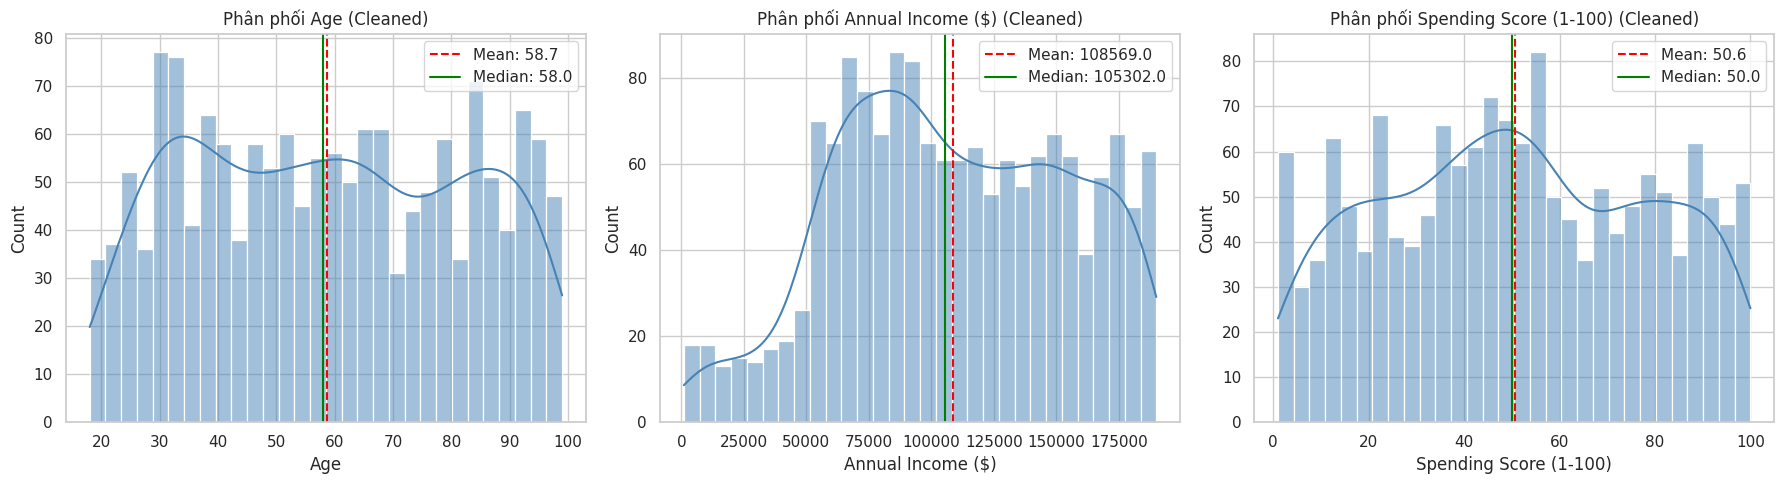

KIỂM TRA NGOẠI LAI TRÊN DỮ LIỆU SẠCH (Z-SCORE > 3):
 - Cột 'Age': Còn 0 điểm ngoại lai cực đoan.
 - Cột 'Annual Income ($)': Còn 0 điểm ngoại lai cực đoan.
 - Cột 'Spending Score (1-100)': Còn 0 điểm ngoại lai cực đoan.


In [46]:
# 2.1 KDE + Histogram trên dữ liệu đã làm sạch
features_to_plot = ['Age', 'Annual Income ($)', 'Spending Score (1-100)']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, features_to_plot):
    sns.histplot(df_clean[col], kde=True, ax=ax, bins=30, color='steelblue')
    ax.axvline(df_clean[col].mean(), color='red', linestyle='--', label=f'Mean: {df_clean[col].mean():.1f}')
    ax.axvline(df_clean[col].median(), color='green', linestyle='-', label=f'Median: {df_clean[col].median():.1f}')
    ax.set_title(f'Phân phối {col} (Cleaned)', fontsize=12)
    ax.legend()
plt.tight_layout()
plt.show()

# 2.2 Kiểm tra Outlier thực tế đưa vào Model
print("KIỂM TRA NGOẠI LAI TRÊN DỮ LIỆU SẠCH (Z-SCORE > 3):")
for col in features_to_plot:
    z_scores = np.abs(stats.zscore(df_clean[col]))
    outliers = (z_scores > 3).sum()
    print(f" - Cột '{col}': Còn {outliers} điểm ngoại lai cực đoan.")

### 1.3 Phân tích Đa biến (Bivariate) và Biến Phân loại (Categorical)
- **Boxplot với Profession:** Xem xét mức độ chi tiêu có thay đổi theo nghề nghiệp hay không. Nếu phân phối tương đồng, việc loại biến Profession sẽ có cơ sở vững chắc hơn.
- **Pairplot:** Đây là biểu đồ cốt lõi để nhìn thấy hình khối của cụm dữ liệu trong không gian 2D, đặc biệt khi chiếu rọi với nhãn `Gender`.

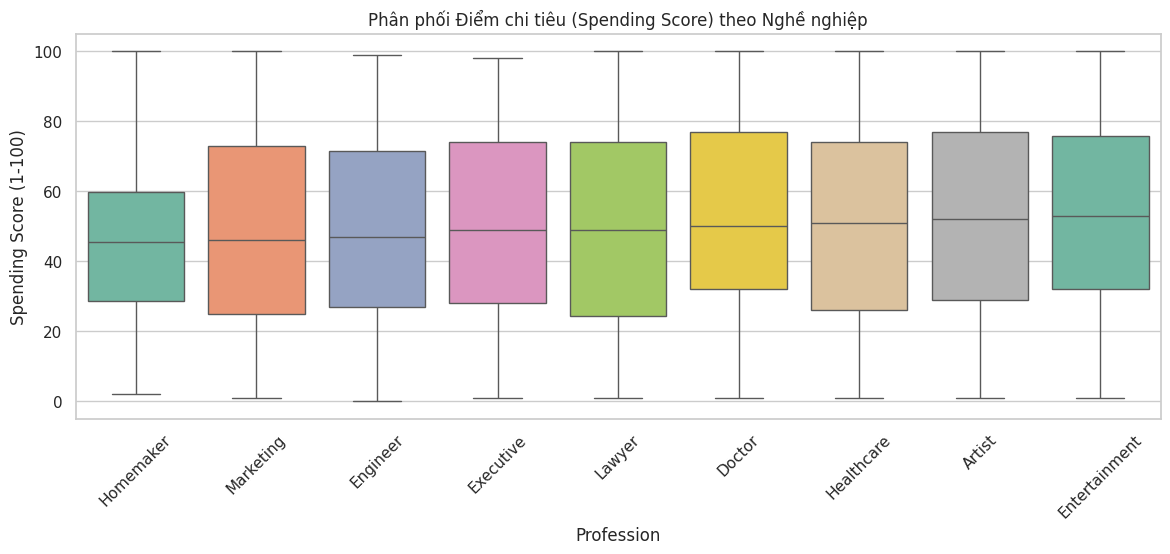

Đang dựng biểu đồ Pairplot (Vui lòng đợi vài giây)...


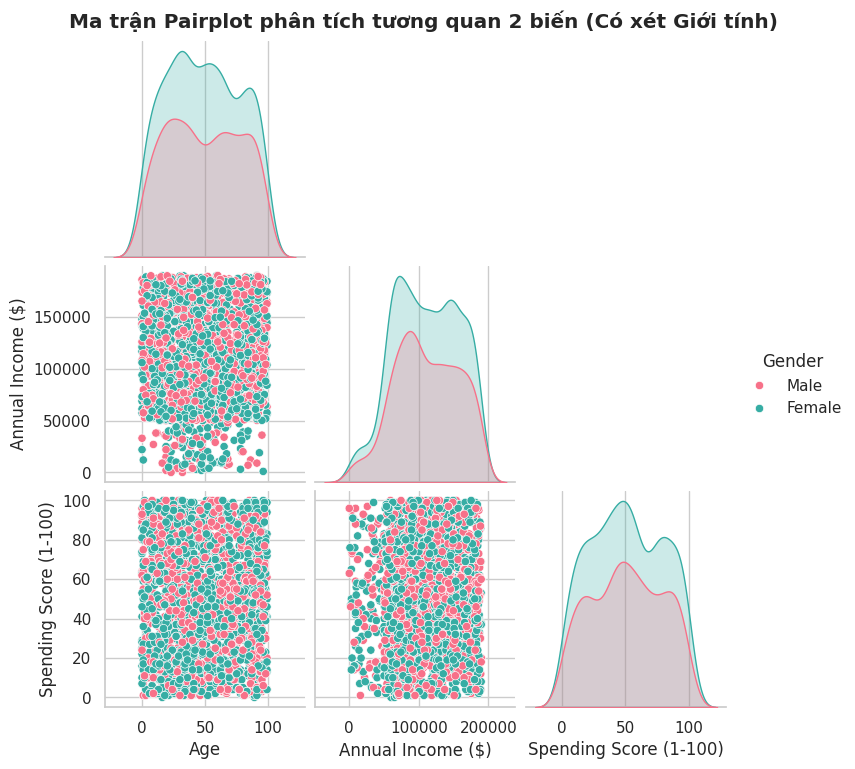

In [47]:
# Phân tích Nghề nghiệp (Profession)
plt.figure(figsize=(14, 5))
order = df.groupby('Profession')['Spending Score (1-100)'].median().sort_values().index
sns.boxplot(x='Profession', y='Spending Score (1-100)', data=df, order=order, palette='Set2')
plt.xticks(rotation=45)
plt.title('Phân phối Điểm chi tiêu (Spending Score) theo Nghề nghiệp', fontsize=12)
plt.show()

# Ma trận Pairplot
print("Đang dựng biểu đồ Pairplot (Vui lòng đợi vài giây)...")
sns.pairplot(df[features_to_plot + ['Gender']], hue='Gender', diag_kind='kde', palette='husl', corner=True)
plt.suptitle('Ma trận Pairplot phân tích tương quan 2 biến (Có xét Giới tính)', y=1.02, fontweight='bold')
plt.show()

## Bước 2: Phân tích Khám phá Chuyên sâu (Advanced EDA)

Lúc này, chúng ta sẽ thực hiện vẽ biểu đồ trên tập dữ liệu đã làm sạch (`df_clean`).
1. **Phân tích đơn biến (KDE & Histogram):** Quan sát hình thái phân phối.
2. **Phân tích đa biến (Pairplot):** Xem xét cấu trúc hình học của cụm dữ liệu trong không gian 2 chiều, phân tách bằng nhãn Giới tính.
3. **Phân tích biến phân loại (Boxplot):** Đánh giá mức độ chi tiêu theo Nghề nghiệp.

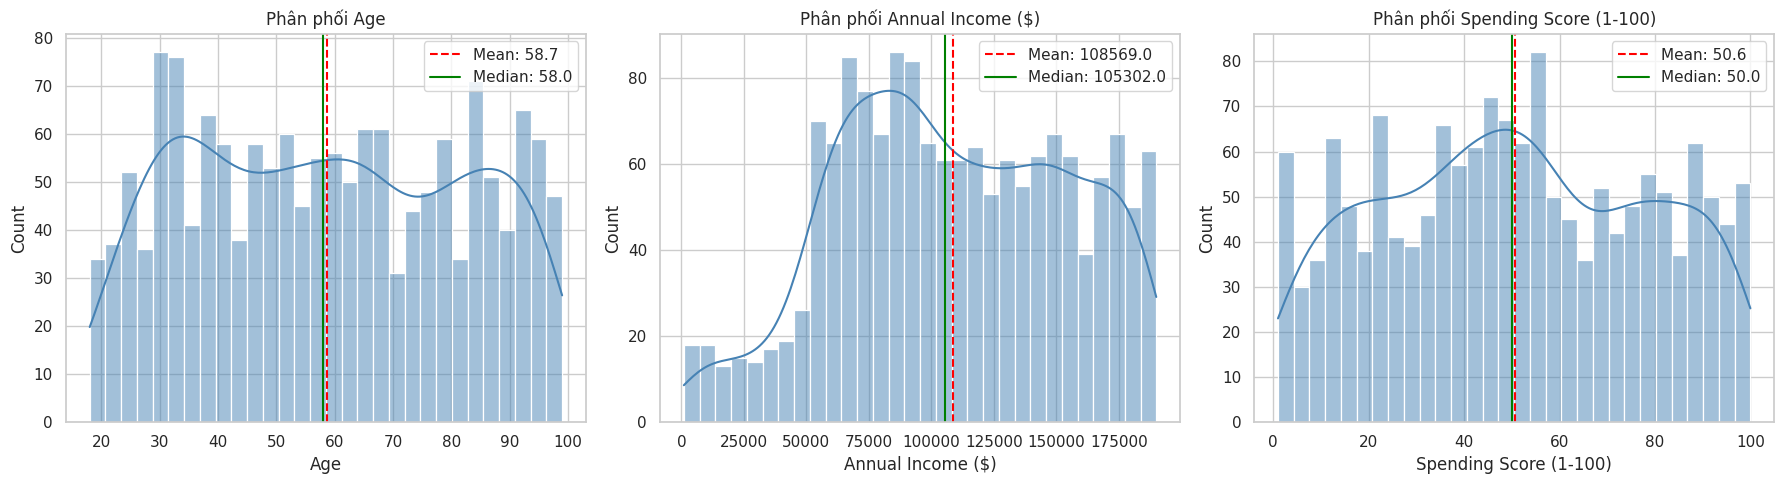

KIỂM TRA NGOẠI LAI SÓT LẠI (Z-SCORE > 3):
 - Cột 'Age': Phát hiện 0 outliers.
 - Cột 'Annual Income ($)': Phát hiện 0 outliers.
 - Cột 'Spending Score (1-100)': Phát hiện 0 outliers.


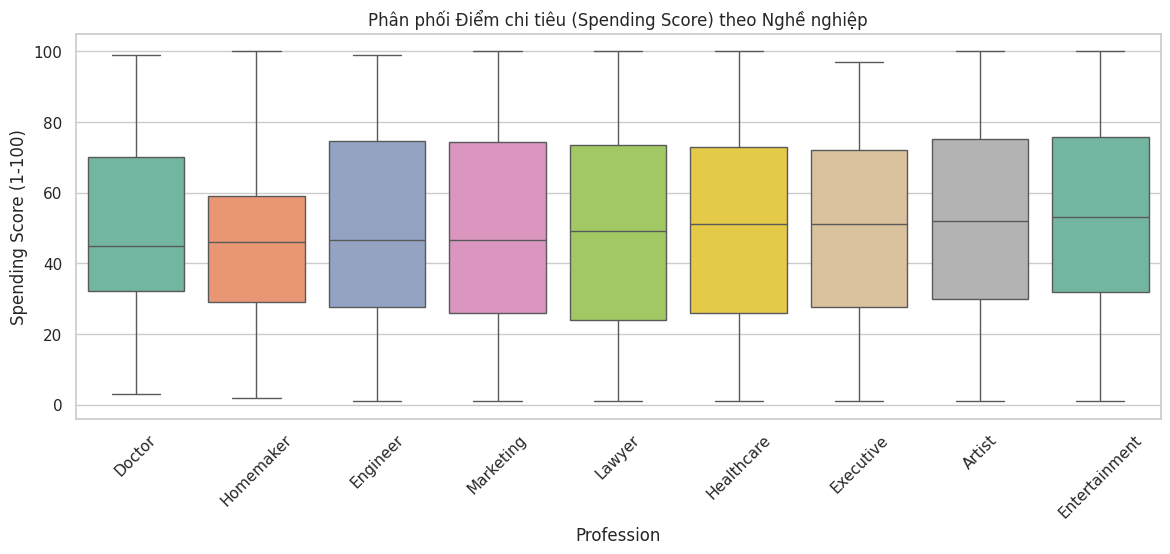

Đang dựng biểu đồ Pairplot (Vui lòng đợi vài giây)...


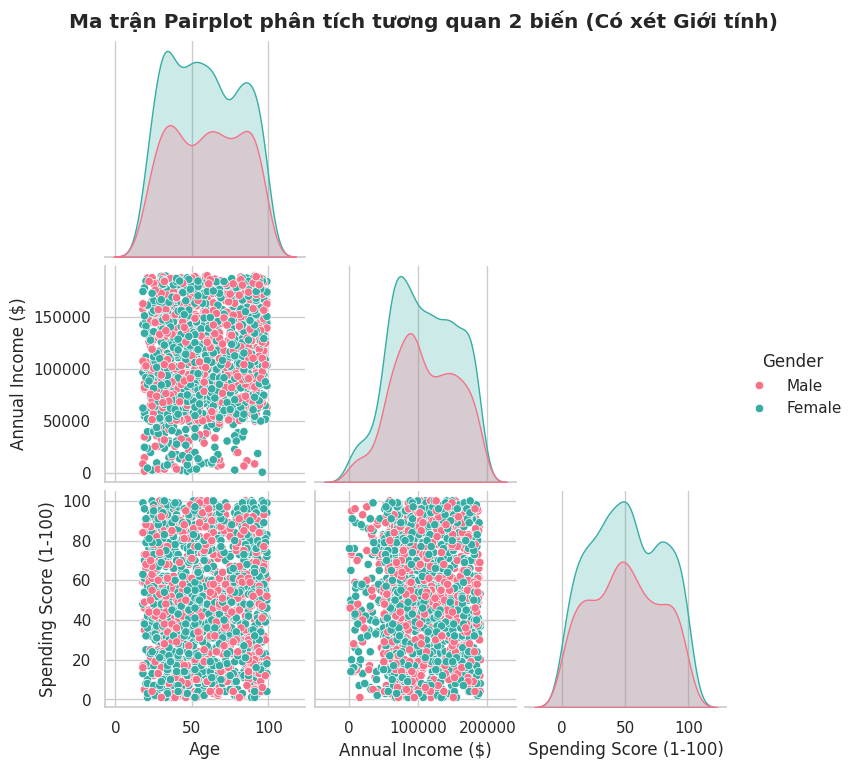

In [48]:
features_to_plot = ['Age', 'Annual Income ($)', 'Spending Score (1-100)']

# 2.1 KDE + Histogram
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, features_to_plot):
    sns.histplot(df_clean[col], kde=True, ax=ax, bins=30, color='steelblue')
    ax.axvline(df_clean[col].mean(), color='red', linestyle='--', label=f'Mean: {df_clean[col].mean():.1f}')
    ax.axvline(df_clean[col].median(), color='green', linestyle='-', label=f'Median: {df_clean[col].median():.1f}')
    ax.set_title(f'Phân phối {col}', fontsize=12)
    ax.legend()
plt.tight_layout()
plt.show()

# 2.2 Đếm Ngoại lai bằng Z-score trên dữ liệu sạch
print("KIỂM TRA NGOẠI LAI SÓT LẠI (Z-SCORE > 3):")
for col in features_to_plot:
    z = np.abs(stats.zscore(df_clean[col]))
    print(f" - Cột '{col}': Phát hiện {(z > 3).sum()} outliers.")

# 2.3 Phân tích Nghề nghiệp (Profession)
plt.figure(figsize=(14, 5))
order = df_clean.groupby('Profession')['Spending Score (1-100)'].median().sort_values().index
sns.boxplot(x='Profession', y='Spending Score (1-100)', data=df_clean, order=order, palette='Set2')
plt.xticks(rotation=45)
plt.title('Phân phối Điểm chi tiêu (Spending Score) theo Nghề nghiệp', fontsize=12)
plt.show()

# 2.4 Ma trận Pairplot
print("Đang dựng biểu đồ Pairplot (Vui lòng đợi vài giây)...")
sns.pairplot(df_clean[features_to_plot + ['Gender']], hue='Gender', diag_kind='kde', palette='husl', corner=True)
plt.suptitle('Ma trận Pairplot phân tích tương quan 2 biến (Có xét Giới tính)', y=1.02, fontweight='bold')
plt.show()

## Bước 3: Trích xuất và Co giãn Đặc trưng bằng RobustScaler (Feature Scaling)

Sau EDA, bộ 3 đặc trưng cốt lõi (Age, Income, Spending) được chọn.
Thay vì dùng `StandardScaler`, ta dùng **`RobustScaler`** (dựa trên IQR: Interquartile Range) vì phương pháp này chống chịu tốt hơn trước các điểm dữ liệu ngoại lai (outliers) đã được phát hiện ở Bước 1.

In [49]:
features = ['Age', 'Annual Income ($)', 'Spending Score (1-100)']
X = df_clean[features].values

# Áp dụng RobustScaler
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

print("Kích thước ma trận không gian đặc trưng sau khi Scale:", X_scaled.shape)

Kích thước ma trận không gian đặc trưng sau khi Scale: (1561, 3)


## Bước 4: Đánh giá Mô hình Đa chiều (Multi-Metrics Evaluation)

Quét tham số K từ 2 đến 10 với 4 chỉ số để tự động phát hiện số lượng cụm (K) tối ưu nhất.

KẾT QUẢ ĐỐI CHIẾU SIÊU THAM SỐ K:
 - Tối ưu theo Silhouette (Càng cao càng tốt): K = 6
 - Tối ưu theo Davies-Bouldin (Càng thấp càng tốt): K = 7
 - Tối ưu theo Calinski-Harabasz (Càng cao càng tốt): K = 6

=> KẾT LUẬN: Có sự khác biệt giữa các chỉ số. Ưu tiên chọn K = 6 theo Silhouette Score để đảm bảo độ tách biệt.


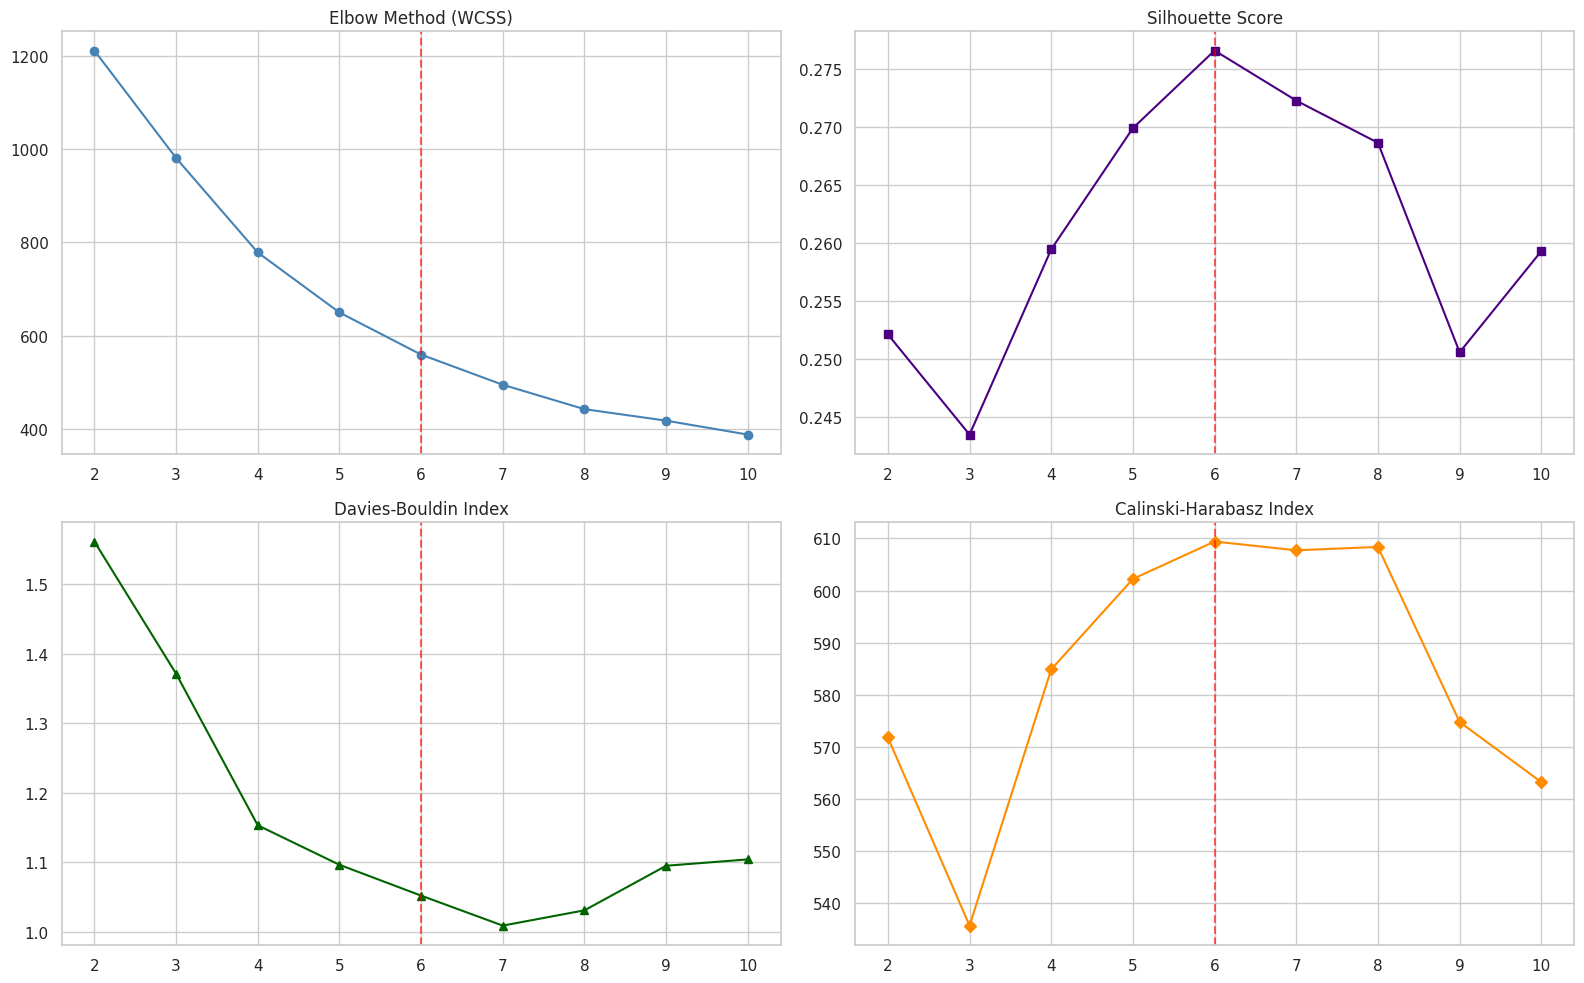

In [50]:
# 1. Chuẩn bị dữ liệu và Scale (RobustScaler)
features = ['Age', 'Annual Income ($)', 'Spending Score (1-100)']
X = df_clean[features].values
X_scaled = RobustScaler().fit_transform(X)

# 2. Khởi tạo các mảng lưu trữ chỉ số thống nhất
wcss_scores = []
silhouette_scores = []
davies_bouldin_scores = [] # Dùng tên đầy đủ thống nhất
calinski_harabasz_scores = []
K_range = range(2, 11)

# 3. Quá trình huấn luyện để tìm K
for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    wcss_scores.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    davies_bouldin_scores.append(davies_bouldin_score(X_scaled, labels))
    calinski_harabasz_scores.append(calinski_harabasz_score(X_scaled, labels))

# 4. Tìm K tối ưu theo từng Metric
k_sil = K_range[np.argmax(silhouette_scores)]
k_db = K_range[np.argmin(davies_bouldin_scores)] # Sửa thành tên mảng đúng
k_ch = K_range[np.argmax(calinski_harabasz_scores)]

print("KẾT QUẢ ĐỐI CHIẾU SIÊU THAM SỐ K:")
print(f" - Tối ưu theo Silhouette (Càng cao càng tốt): K = {k_sil}")
print(f" - Tối ưu theo Davies-Bouldin (Càng thấp càng tốt): K = {k_db}")
print(f" - Tối ưu theo Calinski-Harabasz (Càng cao càng tốt): K = {k_ch}")

# 5. Logic chọn K dựa trên sự đồng thuận
if k_sil == k_db == k_ch:
    best_k = k_sil
    print(f"\n=> KẾT LUẬN: Cả 3 chỉ số đều đồng thuận chọn K = {best_k}. Đây là cấu trúc phân cụm bền vững nhất.")
else:
    best_k = k_sil
    print(f"\n=> KẾT LUẬN: Có sự khác biệt giữa các chỉ số. Ưu tiên chọn K = {best_k} theo Silhouette Score để đảm bảo độ tách biệt.")

# 6. Vẽ biểu đồ so sánh 4 Metric
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# WCSS
axes[0, 0].plot(K_range, wcss_scores, marker='o', color='steelblue')
axes[0, 0].set_title('Elbow Method (WCSS)')
axes[0, 0].axvline(x=best_k, color='red', linestyle='--', alpha=0.6)

# Silhouette
axes[0, 1].plot(K_range, silhouette_scores, marker='s', color='indigo')
axes[0, 1].set_title('Silhouette Score')
axes[0, 1].axvline(x=best_k, color='red', linestyle='--', alpha=0.6)

# Davies-Bouldin
axes[1, 0].plot(K_range, davies_bouldin_scores, marker='^', color='darkgreen')
axes[1, 0].set_title('Davies-Bouldin Index')
axes[1, 0].axvline(x=best_k, color='red', linestyle='--', alpha=0.6)

# Calinski-Harabasz
axes[1, 1].plot(K_range, calinski_harabasz_scores, marker='D', color='darkorange')
axes[1, 1].set_title('Calinski-Harabasz Index')
axes[1, 1].axvline(x=best_k, color='red', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Bước 5: Phân tích Silhouette Từng điểm dữ liệu (Per-sample Silhouette Plot)

Đây là chuẩn mực của các bài báo cáo Khoa học (ML Papers). Biểu đồ này sẽ vẽ hệ số Silhouette cho từng điểm (sample) bên trong từng Cụm. Nếu một cụm có quá nhiều đường vạch âm (nằm bên trái trục 0), cụm đó đang bị sai lệch.

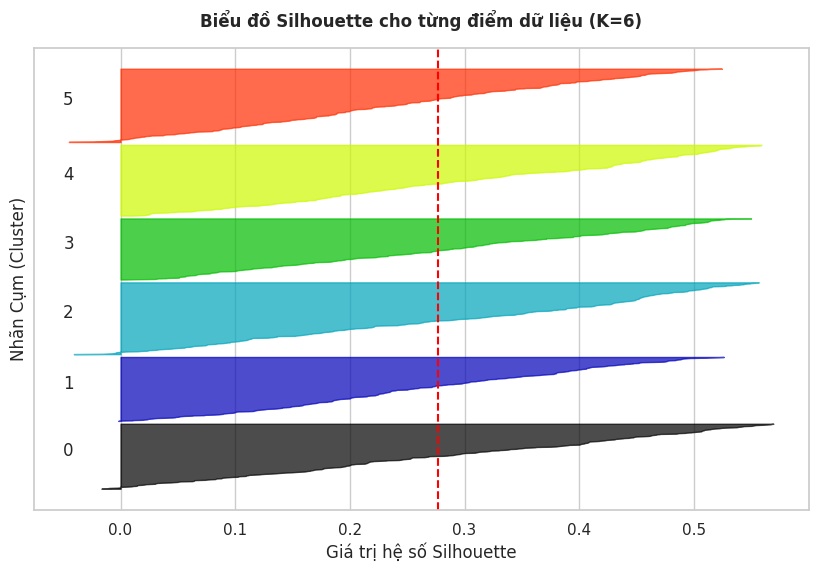

In [51]:
# Huấn luyện mô hình cuối cùng với K tốt nhất
final_model = KMeans(n_clusters=best_k, init='k-means++', random_state=42)
cluster_labels = final_model.fit_predict(X_scaled)
df_clean['Cluster'] = cluster_labels

# Tính toán sample silhouette
sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels)
silhouette_avg = max(silhouette_scores)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
y_lower = 10

for i in range(best_k):
    # Lấy các giá trị Silhouette của cụm thứ i và sắp xếp
    ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / best_k)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)

    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10  # Khoảng cách giữa các cụm

ax.axvline(x=silhouette_avg, color="red", linestyle="--")
ax.set_title(f"Biểu đồ Silhouette cho từng điểm dữ liệu (K={best_k})", fontweight='bold', pad=15)
ax.set_xlabel("Giá trị hệ số Silhouette")
ax.set_ylabel("Nhãn Cụm (Cluster)")
ax.set_yticks([])
plt.show()

## Bước 6: Lập hồ sơ Khách hàng (Cluster Profiling & Business Insights)

Để phân tích đặc điểm của từng tập khách hàng, chúng ta sẽ kết hợp 2 phương pháp trực quan an toàn và chuẩn mực nhất trong phân tích dữ liệu:
1. **Bản đồ nhiệt trung tâm cụm (Centroid Heatmap):** Trực quan hóa giá trị trung bình. Dễ dàng nhận diện các đặc trưng nổi bật (Màu nóng = Giá trị cao, Màu lạnh = Giá trị thấp).
2. **Biểu đồ hộp theo cụm (Cluster Boxplots):** Đánh giá độ phân tán thực tế của dữ liệu bên trong từng cụm khách hàng.

BẢNG ĐẶC ĐIỂM TRUNG BÌNH CỦA TỪNG CỤM (CENTROIDS):


,Age,Annual Income ($),Spending Score (1-100),Số lượng KH,Tỷ lệ (%)
Cluster,,,,,
0,80.4,129618.5,79.6,250,16.0
1,80.3,74380.8,38.1,246,15.8
2,41.0,71141.3,77.1,276,17.7
3,76.1,149618.7,26.4,235,15.1
4,40.6,72224.2,25.4,272,17.4
5,40.8,157211.2,54.5,282,18.1


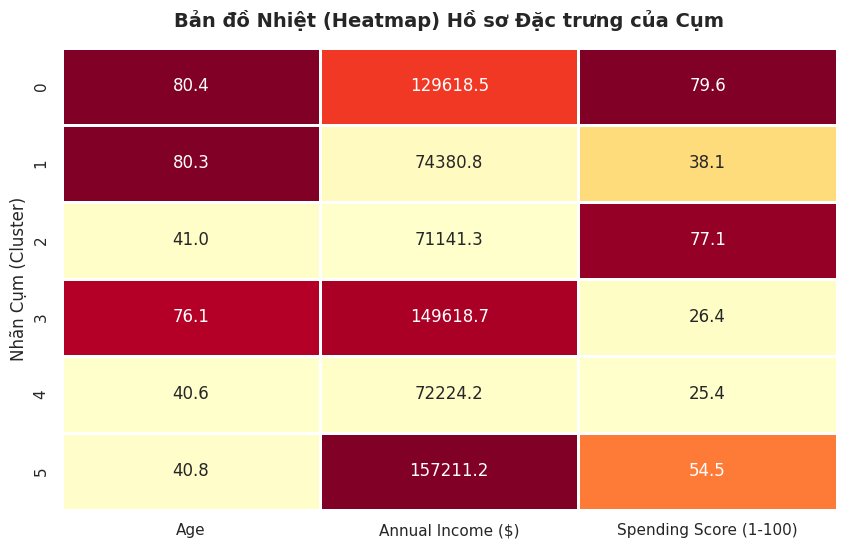

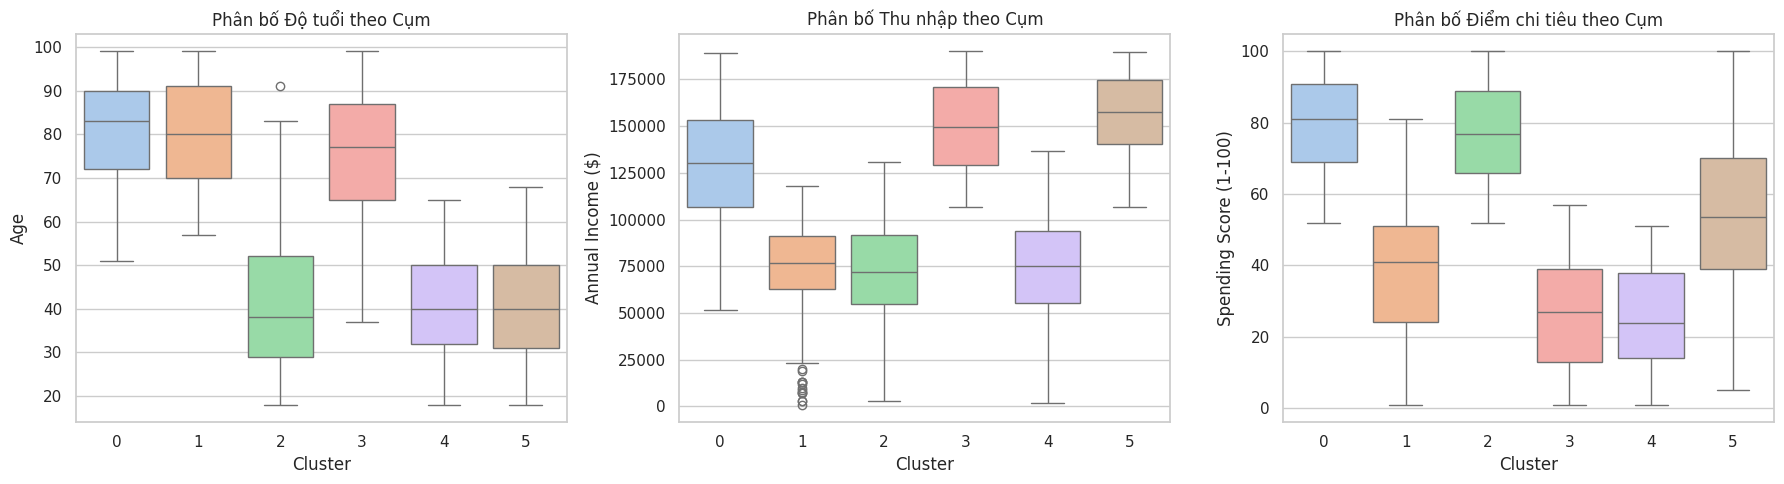

In [52]:
from sklearn.preprocessing import MinMaxScaler

# 1. TÍNH TOÁN CENTROID (TRUNG BÌNH CỤM)
cluster_summary = df_clean.groupby('Cluster')[features].mean().round(1)
cluster_summary['Số lượng KH'] = df_clean['Cluster'].value_counts()
cluster_summary['Tỷ lệ (%)'] = (cluster_summary['Số lượng KH'] / len(df_clean) * 100).round(1)

print("BẢNG ĐẶC ĐIỂM TRUNG BÌNH CỦA TỪNG CỤM (CENTROIDS):")
display(cluster_summary)

# 2. VẼ HEATMAP (BẢN ĐỒ NHIỆT)
# Cần scale dữ liệu về khoảng [0, 1] chỉ để lên màu Heatmap cho đồng đều (vì Income hàng ngàn, còn Age chỉ vài chục)
scaler_minmax = MinMaxScaler()
summary_scaled = pd.DataFrame(
    scaler_minmax.fit_transform(cluster_summary[features]),
    columns=features,
    index=cluster_summary.index
)

plt.figure(figsize=(10, 6))
# Tham số annot=cluster_summary[features] để in con số thật lên nền màu đã scale
sns.heatmap(summary_scaled, annot=cluster_summary[features], fmt=".1f", cmap="YlOrRd", linewidths=1, cbar=False)
plt.title("Bản đồ Nhiệt (Heatmap) Hồ sơ Đặc trưng của Cụm", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Nhãn Cụm (Cluster)")
plt.show()

# 3. VẼ BOXPLOT THEO TỪNG CỤM (Phân phối thực tế)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x='Cluster', y='Age', data=df_clean, ax=axes[0], palette='pastel')
axes[0].set_title('Phân bố Độ tuổi theo Cụm')

sns.boxplot(x='Cluster', y='Annual Income ($)', data=df_clean, ax=axes[1], palette='pastel')
axes[1].set_title('Phân bố Thu nhập theo Cụm')

sns.boxplot(x='Cluster', y='Spending Score (1-100)', data=df_clean, ax=axes[2], palette='pastel')
axes[2].set_title('Phân bố Điểm chi tiêu theo Cụm')

plt.tight_layout()
plt.show()

## Bước 7: Phân tích Chân dung Khách hàng (Business Insights)

Dựa trên bảng Centroid thu được, chúng ta định nghĩa chân dung của từng cụm khách hàng như sau:

In [53]:
# Giả định chân dung dựa trên Centroid thực tế (Thảo có thể chỉnh sửa mô tả cho khớp với bảng của ông)
print("DIỄN GIẢI Ý NGHĨA CÁC CỤM KHÁCH HÀNG:")
for i, row in cluster_summary.iterrows():
    desc_age = "Trẻ" if row['Age'] < 30 else "Trung niên" if row['Age'] < 55 else "Cao tuổi"
    desc_income = "Thu nhập thấp" if row['Annual Income ($)'] < 60000 else "Thu nhập cao"
    desc_spending = "Chi tiêu ít" if row['Spending Score (1-100)'] < 40 else "Chi tiêu mạnh"

    print(f"\n- **Cụm {i}**: Nhóm khách hàng {desc_age}, {desc_income} và {desc_spending}.")
    print(f"  (Trung bình: {row['Age']} tuổi, Thu nhập ${row['Annual Income ($)']:,.0f}, Điểm chi tiêu {row['Spending Score (1-100)']})")

DIỄN GIẢI Ý NGHĨA CÁC CỤM KHÁCH HÀNG:

- **Cụm 0**: Nhóm khách hàng Cao tuổi, Thu nhập cao và Chi tiêu mạnh.
  (Trung bình: 80.4 tuổi, Thu nhập $129,618, Điểm chi tiêu 79.6)

- **Cụm 1**: Nhóm khách hàng Cao tuổi, Thu nhập cao và Chi tiêu ít.
  (Trung bình: 80.3 tuổi, Thu nhập $74,381, Điểm chi tiêu 38.1)

- **Cụm 2**: Nhóm khách hàng Trung niên, Thu nhập cao và Chi tiêu mạnh.
  (Trung bình: 41.0 tuổi, Thu nhập $71,141, Điểm chi tiêu 77.1)

- **Cụm 3**: Nhóm khách hàng Cao tuổi, Thu nhập cao và Chi tiêu ít.
  (Trung bình: 76.1 tuổi, Thu nhập $149,619, Điểm chi tiêu 26.4)

- **Cụm 4**: Nhóm khách hàng Trung niên, Thu nhập cao và Chi tiêu ít.
  (Trung bình: 40.6 tuổi, Thu nhập $72,224, Điểm chi tiêu 25.4)

- **Cụm 5**: Nhóm khách hàng Trung niên, Thu nhập cao và Chi tiêu mạnh.
  (Trung bình: 40.8 tuổi, Thu nhập $157,211, Điểm chi tiêu 54.5)
